# Tuned Modeling — Home Credit Default Risk

**Input**: `app_train_features.parquet` + baseline results from `modeling_baseline.ipynb`  
**Goal**: Push AUC beyond baseline via hyperparameter tuning + interpretability  

Steps:
1. Optuna hyperparameter search on LightGBM (100 trials)
2. Final model with best params — 5-fold OOF evaluation
3. SHAP feature importance (global + local)
4. Probability calibration check
5. Threshold optimization
6. Generate `submission.csv`

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

DATA_DIR   = r'C:\Users\Mahmoud\Desktop\Project\data'
NB_DIR     = r'C:\Users\Mahmoud\Desktop\Project\Notebooks'
TARGET_COL = 'TARGET'
N_FOLDS    = 10

df = pd.read_parquet(rf'{DATA_DIR}\app_train_features.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')

n_neg = (df[TARGET_COL] == 0).sum()
n_pos = (df[TARGET_COL] == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f'Class balance  : {n_neg:,} repaid / {n_pos:,} defaulted')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Loaded: 356,251 rows x 207 cols
Class balance  : 282,682 repaid / 24,825 defaulted
scale_pos_weight: 11.39


In [3]:
# Prepare X and y
train = df[df['is_train']==1]
test = df[df['is_train']==0]
drop_cols = [c for c in [TARGET_COL, 'SK_ID_CURR','is_train'] if c in df.columns]
X = train.drop(columns=drop_cols)
y = train[TARGET_COL].astype(int)

# Convert dtypes for compatibility
bool_cols    = X.select_dtypes(include='bool').columns
float32_cols = X.select_dtypes(include='float32').columns
X[bool_cols]    = X[bool_cols].astype(np.int8)
X[float32_cols] = X[float32_cols].astype(np.float64)

print(f'X shape : {X.shape}')
print(f'Nulls   : {X.isnull().sum().sum()}')

X shape : (307507, 204)
Nulls   : 10047645


## Step 1 — Optuna Hyperparameter Search

In [ ]:
def objective(trial):
    """Optuna objective: 10-fold CV AUC (faster than 5-fold during search)."""
    params = {
        'n_estimators'      : 2000, 
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.03, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 30, 80),
        'max_depth'         : trial.suggest_int('max_depth', 5, 10),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain'    : trial.suggest_float('min_split_gain', 0.0, 1.0),
        'device_type'       : 'gpu',
        'scale_pos_weight'  : scale_pos_weight,
        'metric'            : 'auc',
        'random_state'      : 42,
        'n_jobs'            : -1,
        'verbose'           : -1,
    }

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                # first_metric_only ensures it only looks at AUC, not logloss
                lgb.early_stopping(50, first_metric_only=True, verbose=False),
                lgb.log_evaluation(0)
            ]
        )
        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)


print(f'Starting Optuna search ({100} trials) ...')
study = optuna.create_study(direction='maximize', study_name='lgbm_tuning')
study.optimize(objective, n_trials=100, show_progress_bar=True)
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['metric'] = 'auc'
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1
best_params['n_estimators'] = 2000

print(f'\nBest AUC (3-fold): {study.best_value:.5f}')
print(f'Best params:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

In [22]:
best_params

{'learning_rate': 0.011613337628293557,
 'num_leaves': 39,
 'max_depth': 7,
 'min_child_samples': 83,
 'subsample': 0.4302461598591856,
 'colsample_bytree': 0.4595666638379389,
 'reg_alpha': 7.171860626579346,
 'reg_lambda': 0.00038112221365335566,
 'min_split_gain': 0.815048332656431,
 'scale_pos_weight': 11.386988922457201,
 'metric': 'auc',
 'random_state': 42,
 'n_jobs': -1,
 'verbose': -1,
 'n_estimators': 2000}

In [1]:
best_params = {'learning_rate': 0.011613337628293557,
 'num_leaves': 39,
 'max_depth': 7,
 'min_child_samples': 83,
 'subsample': 0.4302461598591856,
 'colsample_bytree': 0.4595666638379389,
 'reg_alpha': 7.171860626579346,
 'reg_lambda': 0.00038112221365335566,
 'min_split_gain': 0.815048332656431,
 'scale_pos_weight': 11.386988922457201,
 'metric': 'auc',
 'random_state': 42,
 'n_jobs': -1,
 'verbose': -1,
 'n_estimators': 2000}

In [ ]:
# Visualise Optuna trial history
trials_df = study.trials_dataframe()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=trials_df['number'], y=trials_df['value'],
    mode='markers', name='Trial AUC',
    marker=dict(color=trials_df['value'], colorscale='Viridis', size=7,
                colorbar=dict(title='AUC'))
))
# Running best
running_best = trials_df['value'].cummax()
fig.add_trace(go.Scatter(
    x=trials_df['number'], y=running_best,
    mode='lines', name='Best so far',
    line=dict(color='#EF553B', width=2)
))
fig.update_layout(
    title=f'Optuna optimization history -- best AUC={study.best_value:.4f}',
    xaxis_title='Trial', yaxis_title='CV AUC', height=400
)
fig.show()

## Step 2 — Final 5-Fold CV with Best Params

In [5]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(y))
auc_scores = []
models     = []  # store fold models for SHAP
best_params['n_estimators'] = 2000
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False),
                   lgb.log_evaluation(-1)]
    )
    preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = preds

    fold_auc = roc_auc_score(y_val, preds)
    auc_scores.append(fold_auc)
    models.append(model)
    print(f'  Fold {fold}/{N_FOLDS}  AUC={fold_auc:.4f}  best_iter={model.best_iteration_}')

oof_auc   = roc_auc_score(y, oof_preds)
oof_prauc = average_precision_score(y, oof_preds)
gini      = 2 * oof_auc - 1

print(f'\nFinal OOF AUC    : {oof_auc:.4f}')
print(f'Final OOF PR-AUC : {oof_prauc:.4f}')
print(f'Gini coefficient : {gini:.4f}')
print(f'Mean fold AUC    : {np.mean(auc_scores):.4f} +/- {np.std(auc_scores):.4f}')

  Fold 1/10  AUC=0.7891  best_iter=1998
  Fold 2/10  AUC=0.7879  best_iter=1950
  Fold 3/10  AUC=0.8013  best_iter=1828
  Fold 4/10  AUC=0.7955  best_iter=1749
  Fold 5/10  AUC=0.7926  best_iter=1881
  Fold 6/10  AUC=0.7857  best_iter=1883
  Fold 7/10  AUC=0.7940  best_iter=1638
  Fold 8/10  AUC=0.7940  best_iter=1987
  Fold 9/10  AUC=0.7907  best_iter=1777
  Fold 10/10  AUC=0.7901  best_iter=1965

Final OOF AUC    : 0.7920
Final OOF PR-AUC : 0.2873
Gini coefficient : 0.5841
Mean fold AUC    : 0.7921 +/- 0.0042


## Step 3 — SHAP Feature Importance

In [8]:
# Use fold 1 model + a 5000-row sample for speed
shap_model   = models[0]
X_sample     = X.sample(5000, random_state=42)

print('Computing SHAP values (this may take ~1 min) ...')
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_sample)

# For binary classification lgb returns list [neg_class, pos_class]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]   # positive class
else:
    shap_vals = shap_values

# Mean absolute SHAP per feature
mean_shap = pd.DataFrame({
    'feature'   : X.columns,
    'mean_shap' : np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

top30 = mean_shap.head(30)

fig = px.bar(
    top30,
    x='mean_shap', y='feature',
    orientation='h',
    color='mean_shap',
    color_continuous_scale='Plasma',
    title='SHAP -- Top 30 features by mean absolute SHAP value',
)
fig.update_layout(
    height=800,
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False
)
fig.show()

print('\nTop 15 features by SHAP importance:')
print(top30.head(15).to_string(index=False))

Computing SHAP values (this may take ~1 min) ...



Top 15 features by SHAP importance:
                              feature  mean_shap
                      EXT_SOURCE_MEAN   0.224074
                      EXT_SOURCE_PROD   0.099136
                         EXT_SOURCE_3   0.070336
                         EXT_SOURCE_1   0.061454
                CREDIT_TO_GOODS_RATIO   0.057592
                         EXT_SOURCE_2   0.056370
                          CODE_GENDER   0.038987
                           DAYS_BIRTH   0.030828
 NAME_EDUCATION_TYPE_Higher_education   0.030450
            Installments_ins_DPD_MEAN   0.021621
              BUREAU_DAYS_CREDIT_MEAN   0.020306
PREV_CREDIT_TO_APPLICATION_RATIO_MEAN   0.020046
                 ANNUITY_CREDIT_RATIO   0.018925
                          OWN_CAR_AGE   0.015882
                PREV_WAS_REFUSED_MEAN   0.014763


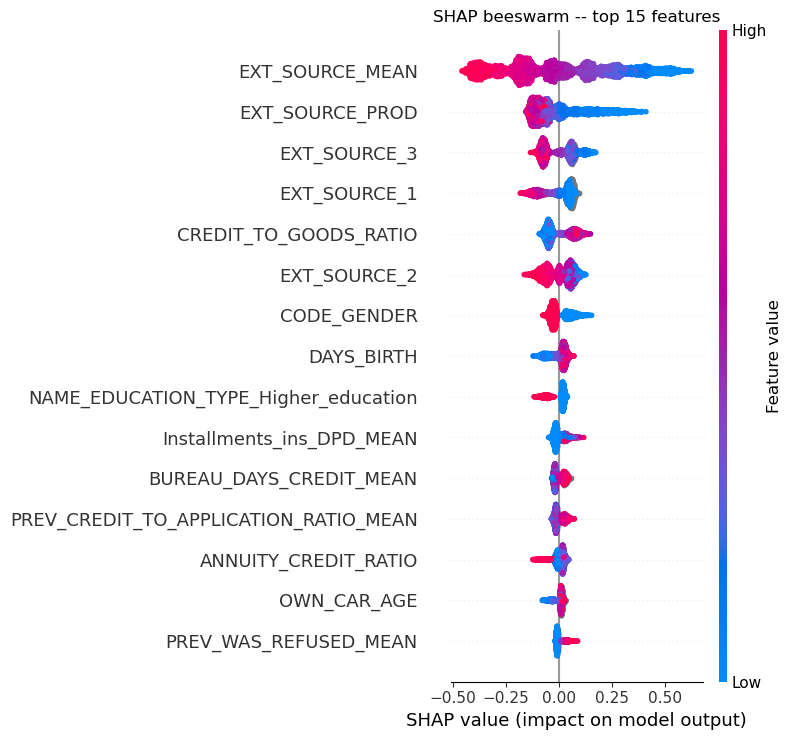

In [ ]:
top15_feats = mean_shap.head(15)['feature'].tolist()
top15_idx   = [list(X.columns).index(f) for f in top15_feats]

shap.summary_plot(
    shap_vals[:, top15_idx],
    X_sample[top15_feats],
    feature_names=top15_feats,
    plot_type='dot',
    show=False
)
plt.title('SHAP beeswarm -- top 15 features')
plt.tight_layout()
plt.show()

## Step 5 — Threshold Optimization

In [35]:
thresholds = np.arange(0.05, 0.80, 0.01)
f1_scores, prec_scores, rec_scores = [], [], []

for t in thresholds:
    preds_bin = (oof_preds >= t).astype(int)
    f1_scores.append(f1_score(y, preds_bin, zero_division=0))
    prec_scores.append(precision_score(y, preds_bin, zero_division=0))
    rec_scores.append(recall_score(y, preds_bin, zero_division=0))

best_t_idx  = np.argmax(f1_scores)
best_thresh = thresholds[best_t_idx]

fig = go.Figure()
fig.add_trace(go.Scatter(x=thresholds, y=f1_scores,   name='F1',        line=dict(color='#636EFA', width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=prec_scores, name='Precision', line=dict(color='#00CC96', width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=rec_scores,  name='Recall',    line=dict(color='#EF553B', width=2)))
fig.add_vline(x=best_thresh, line_dash='dash', line_color='gold',
              annotation_text=f'Best F1 threshold={best_thresh:.2f}')
fig.update_layout(
    title='Precision / Recall / F1 vs classification threshold',
    xaxis_title='Threshold', yaxis_title='Score', height=450
)
fig.show()

print(f'Best threshold (max F1): {best_thresh:.2f}')
print(f'  F1       = {f1_scores[best_t_idx]:.4f}')
print(f'  Precision= {prec_scores[best_t_idx]:.4f}')
print(f'  Recall   = {rec_scores[best_t_idx]:.4f}')

Best threshold (max F1): 0.67
  F1       = 0.3429
  Precision= 0.2786
  Recall   = 0.4458


## Step 6 — Generate Submission File

In [10]:
import joblib

# 1. Prepare your best parameters (Remove early stopping/metrics)
lgb_final_params = best_params.copy()
lgb_final_params['n_estimators'] = 1866  # Set to your average best_iter

# Remove parameters that require a validation set
lgb_final_params.pop('metric', None)

# 2. Train on 100% of the data
print("Training final LightGBM model on the complete dataset...")
final_lgb_model = lgb.LGBMClassifier(**lgb_final_params)
final_lgb_model.fit(X, y)

joblib.dump(final_lgb_model, r"C:\Users\Mahmoud\Desktop\Project - Copy\Notebooks\model\final_model.pkl")
print("LightGBM saved successfully!")

Training final LightGBM model on the complete dataset...
LightGBM saved successfully!
